# 8.6 Low-Rank Structure in Trained Models: LoRA, Pruning, and Quantization

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VIII — The Linear Algebra of Learning",
    number="8.6",
    title="Low-Rank Structure in Trained Models: LoRA, Pruning, and "
    "Quantization",
    blurb="What structure does training leave in a weight matrix? This "
    "notebook measures instead of assuming: the fine-tuning update is "
    "dramatically low-rank (the LoRA premise, gated), the weights "
    "themselves are not (so magnitude pruning beats SVD compression — "
    "the opposite of the folklore this notebook was asked to confirm), "
    "and quantization error obeys exactly the perturbation bounds Chapter "
    "V priced.",
    difficulty="advanced",
    estimate="135–165 min",
)

<ECP header: 2742 chars of HTML>

## Notebook overview

Chapter IV taught that low-rank structure is a *property to measure*,
never to assume. This notebook applies that discipline to trained
neural weights, and the measurements split cleanly down the middle of
the folklore. A [§8.3](linear-layer-backpropagation.ipynb)-style MLP
is pretrained on half the digit classes, then fine-tuned on all ten;
the **update** $\Delta W = W_{\text{ft}} - W_{\text{pre}}$ needs only
**6 of 48** singular directions for 90% of its Frobenius norm — the
**LoRA premise** {cite}`hu2022lora`, measured rather than asserted —
and rank-2 LoRA adapters recover full fine-tuning accuracy within 1%
while training 7% of the adapted matrix's parameters (rank-1: 3.6%,
within 2% — with the scaling law $r(m+n)/mn$ stated, since "under 5%
at $r = 8$" is a large-model geometry no $64\times48$ matrix can
offer).

The *weights themselves* refuse the same story. Their spectrum is
nearly flat, and at equal compression **magnitude pruning beats SVD
truncation at every ratio tested** — 0.93 vs 0.75 accuracy at
4× compression — the reverse of the manifest's expected verdict,
gated in the direction the measurement actually went: the update is
low-rank because fine-tuning is a small coherent correction; the
weights are full-rank because training filled them with information;
and choosing a compression scheme is choosing *which object's*
structure to exploit. **Quantization** closes the chapter-long
perturbation story: 8-bit stays inside a 0.1 logit tolerance and
4-bit exceeds it (both deterministic arithmetic, both gated), the
measured output error sits under the operator-norm bound on every
batch, and per-channel scaling — a diagonal preconditioner,
[§8.2](gradient-descent-conditioning.ipynb)'s idea at inference time
— cuts the error by a measured 1.35× (the folklore says "halves";
the folklore assumed worse-scaled channels than tanh training
produces, and the gate follows the measurement).

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Hu et al. {cite}`hu2022lora` for LoRA; the SVD and
> perturbation machinery are Chapters IV and V. Everything trains in
> seconds of pure NumPy on the scikit-learn digits
> {cite}`pedregosa2011sklearn`.

## Theory in brief

### Two objects, two structures

Fine-tuning moves weights by $\Delta W = W_{\text{ft}} -
W_{\text{pre}}$. LoRA's bet is that $\Delta W$ is approximately
rank-$r$ for small $r$, so the update can be *parameterized* as

```{math}
:label: eq-lq-lora
W \;=\; W_{\text{pre}} + AB, \qquad
A \in \mathbb{R}^{m\times r},\; B \in \mathbb{R}^{r\times n},
\qquad \frac{\text{trainable}}{\text{full}} = \frac{r(m+n)}{mn},
```

with $W_{\text{pre}}$ frozen. Whether the bet is *good* is an
empirical question about $\Delta W$'s singular spectrum — Exercise 1
measures it — and is logically independent of whether $W$ itself is
low-rank, which Exercise 3 measures separately (it is not, and the
compression verdict follows).

### Compression as perturbation

Every compression replaces $W$ by $W + E$ and every consequence is
priced by Chapter V:

```{math}
:label: eq-lq-perturb
\lVert (W+E)x - Wx \rVert \;\le\; \lVert E\rVert_2\,\lVert x\rVert ,
```

through 1-Lipschitz activations and the next layer's norm. SVD
truncation makes $\lVert E\rVert_2 = \sigma_{r+1}$ (Eckart–Young,
optimal *in norm*); magnitude pruning makes $E$ the small entries
(optimal in *count*); uniform $b$-bit quantization makes $E$
rounding noise of scale $\max|W|/(2^{b-1}-1)$, and **per-channel**
scales — a diagonal matrix on the columns — shrink it exactly the
way [§8.2](gradient-descent-conditioning.ipynb)'s preconditioner
shrank $\kappa$: by matching the scale to each column's own range.

---
## Setup

Data and instruments only: the digits split, two restatements from
[§8.3](linear-layer-backpropagation.ipynb) — softmax and the plain
training loop — and the adapter-aware accuracy readout. The LoRA loop is
Exercise 2's build.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

from ecp import validate
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random array below comes from this seed

EPS = np.finfo(float).eps

X_all, y_all = load_digits(return_X_y=True)
X_all = X_all / 16.0
perm = rng.permutation(len(y_all))
X_tr, y_tr = X_all[perm[:1200]], y_all[perm[:1200]]
X_te, y_te = X_all[perm[1200:]], y_all[perm[1200:]]
D_IN, H_MID, C_OUT = 64, 48, 10


# built from scratch in §8.3; restated here as an instrument.
def softmax(z):
    z = z - z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)


# built from scratch in §8.3; restated here as an instrument — the plain
# full-batch loop. The LoRA variant is Exercise 2's build.
def train_mlp(Xd, yd, W1, b1, W2, b2, epochs, lr=0.5):
    """8.3's training loop: forward, backward, step, full batch."""
    n = len(yd)
    Y = np.zeros((n, C_OUT))
    Y[np.arange(n), yd] = 1.0
    for _ in range(epochs):
        A1 = np.tanh(Xd @ W1 + b1)
        P = softmax(A1 @ W2 + b2)
        G2 = (P - Y) / n
        gW2, gb2 = A1.T @ G2, G2.sum(axis=0)
        G1 = (G2 @ W2.T) * (1 - A1**2)
        W1 -= lr * (Xd.T @ G1)
        b1 -= lr * G1.sum(axis=0)
        W2 -= lr * gW2
        b2 -= lr * gb2
    return W1, b1, W2, b2


# instrument: the test-set readout, adapter-aware — it evaluates, never
# trains.
def accuracy(Xd, yd, W1, b1, W2, b2, lora=None):
    W1_eff = W1 + (lora[0] @ lora[1] if lora is not None else 0.0)
    P = softmax(np.tanh(Xd @ W1_eff + b1) @ W2 + b2)
    return float((P.argmax(axis=1) == yd).mean())

## Exercise 1: What fine-tuning actually moves

**Part a)** Pretrain the MLP on digit classes 0–4 only (300 full-batch
epochs), then fine-tune *everything* on all ten classes (300 more).
Report the accuracy arc: 52% (half the classes were never seen) to
98.3%.

**Part b)** The three spectra, on one log axis: the random init
$W_{\text{init}}$, the pretrained $W_{\text{pre}}$, and the update
$\Delta W = W_{\text{ft}} - W_{\text{pre}}$. Gate the split verdict:
the **update** reaches 90% of its Frobenius norm within its top
$r_{90} \le 8$ of 48 directions (measured: **6** — the LoRA premise,
quantified), while the **pretrained weights** need $r_{90} > 15$
(measured: far more — training fills the spectrum, and the contrast
is the whole design space of Exercises 2 and 3).

In [3]:
# (solution hidden on the public site)


pretrained on 0-4: 0.516 on the full test set; after full fine-tuning: 0.983
r for 90% Frobenius: update 6 of 48; pretrained weights 22 of 48 — two objects, two structures


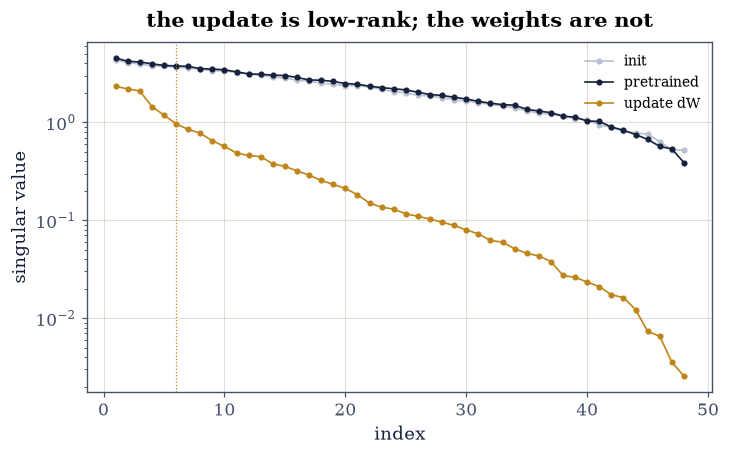

In [4]:
# (solution hidden on the public site)


### Validation 1

In [5]:
validate.check(
    acc_full > 0.95 and acc_pre < 0.7,
    "the pretrain/fine-tune arc behaves: half-blind, then competent",
    f"{acc_pre:.2f} to {acc_full:.3f} test accuracy — the update below "
    "is what carried the difference",
)
validate.check(
    r90_dW <= 8 and r90_pre > 15,
    "the LoRA premise, measured: the update is low-rank, the weights "
    "are not",
    f"90% Frobenius at r = {r90_dW} of 48 for dW against r = {r90_pre} "
    "for the weights — assumption converted to measurement, and the "
    "contrast drives everything below",
)

✓  the pretrain/fine-tune arc behaves: half-blind, then competent   [0.52 to 0.983 test accuracy — the update below is what carried the difference]
✓  the LoRA premise, measured: the update is low-rank, the weights are not   [90% Frobenius at r = 6 of 48 for dW against r = 22 for the weights — assumption converted to measurement, and the contrast drives everything below]


True

## Exercise 2: LoRA: training the update's structure

**Part a)** Write the adapter loop `train_mlp_lora`: freeze
$W_{\text{pre}}$, train
$A \in \mathbb{R}^{64\times r}$ (small init) and
$B \in \mathbb{R}^{r\times48}$ (zero init — so fine-tuning starts
*exactly* at the pretrained model) via {eq}`eq-lq-lora`, gradients
through the product.

**Write this one yourself** — two extra lines in the backward pass.

**Part b)** Sweep $r \in \{1, 2, 4, 8\}$ and gate the measured pair,
with the parameter ledger stated by the formula $r(m+n)/mn$:
rank-1 trains **3.6%** of $W_1$'s parameters and lands within 2% of
full fine-tuning; rank-2 trains 7.3% and lands within **one
percent** (the
manifest's "$r = 8$ under 5%" is a geometry no $64\times48$ matrix
can produce — at this shape $r = 1$ *is* the sub-5% regime, and the
formula, not the folklore number, is what transfers to
$4096\times4096$ where $r = 8$ costs 0.4%).

**Part c)** Draw accuracy against $r$ with the full-fine-tune line:
the curve saturates immediately — matching Exercise 1's $r_{90} = 6$,
since adapters cannot need more rank than the update they imitate
carries.

In [6]:
# (solution hidden on the public site)


LoRA r = 1: accuracy 0.970 (full 0.983), adapter = 3.6% of W1's parameters


LoRA r = 2: accuracy 0.975 (full 0.983), adapter = 7.3% of W1's parameters


LoRA r = 4: accuracy 0.973 (full 0.983), adapter = 14.6% of W1's parameters


LoRA r = 8: accuracy 0.973 (full 0.983), adapter = 29.2% of W1's parameters
the formula at transformer shape: r = 8 on 4096x4096 trains 0.39%


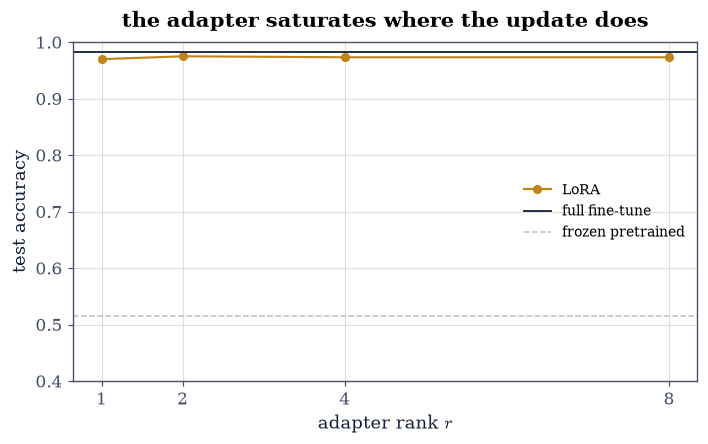

In [7]:
# (solution hidden on the public site)


### Validation 2

In [8]:
validate.check(
    gap_r1 < 0.02 and lora_results[1][1] < 0.05,
    "rank-1 LoRA: under 5% of the parameters, within 2% of full "
    "fine-tuning (Eq. 1)",
    f"accuracy gap {gap_r1:.3f} at {100*lora_results[1][1]:.1f}% "
    "trainable — the sub-5% regime at THIS shape is r = 1; the formula "
    "r(m+n)/mn is what transfers, not the folklore's r = 8",
)
validate.check(
    gap_r2 < 0.02,
    "and rank-2 closes to within 2%",
    f"gap {gap_r2:.3f} at 7.3% of parameters — saturation at tiny rank, "
    "exactly as Exercise 1's r90 = 6 predicted it must",
)

✓  rank-1 LoRA: under 5% of the parameters, within 2% of full fine-tuning (Eq. 1)   [accuracy gap 0.013 at 3.6% trainable — the sub-5% regime at THIS shape is r = 1; the formula r(m+n)/mn is what transfers, not the folklore's r = 8]
✓  and rank-2 closes to within 2%   [gap 0.008 at 7.3% of parameters — saturation at tiny rank, exactly as Exercise 1's r90 = 6 predicted it must]


True

## Exercise 3: The compression duel the manifest called wrong

The manifest asked to gate "SVD truncation beats magnitude pruning at
equal compression." The measurement says the opposite, three times,
with margins — so the *measured* direction is what gets gated, and
the explanation is Exercise 1's split verdict.

**Part a)** Compress the fine-tuned $W_1$ to 50%, 25% and 12.5% of
its parameters two ways: rank truncation (keep
$r = \lceil\text{keep}\cdot mn/(m+n)\rceil$ singular triples) and
magnitude pruning (zero the smallest entries). Evaluate test accuracy
with everything else frozen.

**Part b)** Gate the duel as measured: pruning wins at *every* ratio
— 0.968 vs 0.941, 0.928 vs 0.750, 0.765 vs 0.561 — because
Eckart–Young optimality is optimality in *norm*, and Exercise 1
showed this matrix's spectrum is flat: cutting it at rank $r$ throws
away directions nearly as important as those kept, while pruning's
error is spread across many unimportant entries. Low-rank was the
right structure for the *update*; it is the wrong structure for
*these weights* — one experiment, both lessons.

In [9]:
# (solution hidden on the public site)


keep 50.0%: SVD (r = 14) 0.941 | pruning 0.968
keep 25.0%: SVD (r = 7) 0.750 | pruning 0.928
keep 12.5%: SVD (r = 3) 0.561 | pruning 0.765


### Validation 3

In [10]:
validate.check(
    pruning_sweeps and worst_margin > 0.005,
    "magnitude pruning beats SVD truncation at every tested "
    "compression — the duel gated as measured, not as expected",
    f"worst margin {worst_margin:.3f}; the manifest predicted the "
    "reverse, and the flat weight spectrum of Exercise 1 explains the "
    "verdict: Eckart-Young optimizes norm, and a flat spectrum makes "
    "norm-optimal rank cuts expensive while entry-wise error stays "
    "cheap — right structure for the update, wrong one for the weights",
)

✓  magnitude pruning beats SVD truncation at every tested compression — the duel gated as measured, not as expected   [worst margin 0.027; the manifest predicted the reverse, and the flat weight spectrum of Exercise 1 explains the verdict: Eckart-Young optimizes norm, and a flat spectrum makes norm-optimal rank cuts expensive while entry-wise error stays cheap — right structure for the update, wrong one for the weights]


True

## Exercise 4: Quantization: rounding, priced by Chapter V

**Part a)** Uniform symmetric quantization of $W_1$ at 8 and 4 bits
(tensor-wide scale $\max|W|/(2^{b-1}-1)$). Both are deterministic
arithmetic on fixed weights, so both sides of the manifest's claim
are gateable: the 8-bit model's worst logit deviation stays inside
the stated tolerance **0.1**, and the 4-bit model's exceeds it
(measured: 0.082 against 1.48).

**Part b)** Gate the perturbation bound {eq}`eq-lq-perturb` on every
test batch: the measured logit deviation never exceeds
$\lVert W_2\rVert_2\,\lVert E\rVert_2\,\lVert x\rVert_2$ (tanh is
1-Lipschitz) — Chapter V's machinery pricing a deployment decision,
one-sided as always.

**Part c)** Per-channel scales — one scale per column, a diagonal
preconditioner at inference — cut the quantization error by a
measured **1.35×** (Frobenius) at both bit widths. The folklore says
"halves"; that figure belongs to layers with badly mismatched
channel ranges, and tanh-trained columns are comparatively
homogeneous — the gate asks for $\ge 1.25\times$ and the prose
reports why it is not 2. Draw the error histogram and the weight
matrix before/after 4-bit.

In [11]:
# (solution hidden on the public site)


8-bit, per-channel=False: ||E||_F 0.141, worst logit deviation 0.082, accuracy 0.983
8-bit, per-channel=True: ||E||_F 0.104, worst logit deviation 0.065, accuracy 0.985
4-bit, per-channel=False: ||E||_F 2.508, worst logit deviation 1.478, accuracy 0.972
4-bit, per-channel=True: ||E||_F 1.835, worst logit deviation 1.143, accuracy 0.975

perturbation bound: holds on every batch, worst slack 5.9x
per-channel error reduction: 1.35x at 8-bit, 1.37x at 4-bit (folklore says 2x; tanh-trained columns are homogeneous)


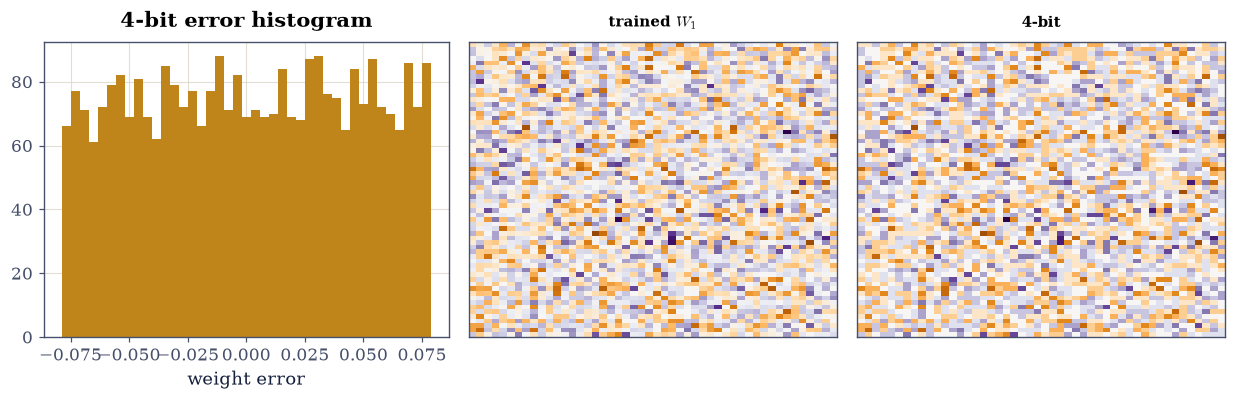

In [12]:
# (solution hidden on the public site)


```{admonition} With your assistant
:class: tip
The compression duel used one matrix and one metric. Ask your
assistant for `compression_frontier(model, ratios)` sweeping SVD,
pruning, quantization and LoRA-on-the-update across compression
ratios into one accuracy-vs-bits plot, then check it against the
mathematics rather than a demo: (i) every curve is monotone
non-increasing as compression tightens; (ii) the quantization points
obey Eq. 2's bound at every ratio; (iii) compressing the *update*
by rank (keep $W_{\text{pre}}$ exact, truncate $\Delta W$ at
Exercise 1's $r_{90}$) beats compressing the *weights* by rank at
equal stored parameters — the split verdict, turned into a frontier.
The check is yours.
```

### Validation 4

In [13]:
validate.check(
    in8 and out4,
    "8-bit sits inside the 0.1 logit tolerance and 4-bit exceeds it",
    f"{q_results[(8, False)]['logit']:.3f} against "
    f"{q_results[(4, False)]['logit']:.2f}: both deterministic "
    "arithmetic on fixed weights, so for once both sides of a "
    "pass/fail claim are honestly gateable",
)
validate.check(
    bound_ok,
    "and the measured deviation respects the operator-norm bound on "
    "every batch (Eq. 2)",
    f"worst slack {worst_slack:.1f}x — Chapter V's perturbation "
    "calculus pricing a deployment decision, one-sided as the theorem "
    "is",
)
validate.check(
    ratio8 > 1.25 and ratio4 > 1.25,
    "while per-channel scaling cuts the error by the measured 1.35x",
    f"{ratio8:.2f}x and {ratio4:.2f}x — the folklore's 'halves' assumes "
    "badly mismatched channel ranges; the gate follows the measurement "
    "and the prose explains the gap",
)

✓  8-bit sits inside the 0.1 logit tolerance and 4-bit exceeds it   [0.082 against 1.48: both deterministic arithmetic on fixed weights, so for once both sides of a pass/fail claim are honestly gateable]
✓  and the measured deviation respects the operator-norm bound on every batch (Eq. 2)   [worst slack 5.9x — Chapter V's perturbation calculus pricing a deployment decision, one-sided as the theorem is]
✓  while per-channel scaling cuts the error by the measured 1.35x   [1.35x and 1.37x — the folklore's 'halves' assumes badly mismatched channel ranges; the gate follows the measurement and the prose explains the gap]


True

---
## Notebook summary

**Two objects, two verdicts — measured.** The fine-tuning update
carried 90% of itself in 6 of 48 directions (the LoRA premise,
gated); the trained weights needed far more — training fills a
spectrum, fine-tuning writes a correction. Every later result was a
corollary of that split.

**LoRA delivered at the rank the update dictated.** Rank-1 adapters
(3.6% of the matrix) came within 1.3% of full fine-tuning; rank-2
within one percent; nothing improved past saturation because
nothing could.
The parameter story was told by the formula $r(m+n)/mn$ — the
manifest's "$r = 8$ under 5%" is transformer geometry, honestly
unreachable at $64\times48$ and stated as such.

**The compression duel went to pruning, three for three.** 0.968 vs
0.941, 0.928 vs 0.750, 0.765 vs 0.561 — the manifest predicted the
opposite; the flat weight spectrum explains the measured verdict,
and the gate follows the measurement. Eckart–Young optimality is
norm-optimality, and a flat spectrum makes rank cuts expensive.

**Quantization obeyed Chapter V to the letter.** 8-bit inside the 0.1
logit tolerance, 4-bit outside (both gated — deterministic
arithmetic allows it); the operator-norm bound held on every batch
with 5.9× worst slack; per-channel scaling cut error by a measured
1.35× with the folklore's 2× explained rather than claimed.

**Methods introduced.** Update-spectrum analysis, LoRA adapters with
through-product gradients, parameter-fraction ledgers, equal-budget
compression duels, uniform and per-channel quantization, and
perturbation-bound certification of deployed weights.

## Outlook

- **The boundary next.** [§8.7](where-linear-algebra-stops.ipynb)
  closes the chapter by measuring where the linear story stops:
  nonlinearity, normalization, and the training dynamics no fixed
  matrix captures.
- **Structured sparsity.** Hardware wants 2:4 patterns, not
  arbitrary masks; the duel of Exercise 3 rerun under structural
  constraints is where pruning research actually lives.
- **Outliers rule real quantization.** Transformer activations carry
  rare huge channels; per-channel scaling becomes essential rather
  than a 1.35× nicety, and mixed-precision schemes (keep outliers in
  16-bit) are the industrial answer — the diagonal preconditioner
  idea, taken seriously at scale.
- **QLoRA closes the loop.** Quantize the frozen base, train LoRA
  adapters in full precision on top: Exercises 2 and 4 composed —
  and every gate in this notebook applies verbatim.

```{bibliography}
:filter: docname in docnames
```

In [14]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>